In [1]:
# 1. Remove the standard MediaPipe that is clashing
!pip uninstall -y mediapipe protobuf

# 2. Install the modern versions that support NumPy 2.0+ and Protobuf 5.x
# We use the '--no-cache-dir' to ensure we don't grab a broken local copy
!pip install --no-cache-dir mediapipe==0.10.14
!pip install --no-cache-dir protobuf==5.29.5


Found existing installation: protobuf 5.29.5
Uninstalling protobuf-5.29.5:
  Successfully uninstalled protobuf-5.29.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 307.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 368.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.25 requires protobuf>=5.29.5, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 

In [2]:
import mediapipe as mp
import pandas as pd
import numpy as np
import tensorflow as tf

print(f"✅ MediaPipe Version: {mp.__version__}")
try:
    # This is the line that was failing
    print(f"✅ Solutions Check: {mp.solutions.hands}")
    print("✅ IT IS WORKING!")
except AttributeError:
    print("❌ STILL FAILING: The attribute is still missing.")


2026-04-27 06:52:24.023163: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777272744.216699      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777272744.271122      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777272744.688084      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777272744.688132      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777272744.688134      23 computation_placer.cc:177] computation placer alr

✅ MediaPipe Version: 0.10.14
✅ Solutions Check: <module 'mediapipe.python.solutions.hands' from '/usr/local/lib/python3.12/dist-packages/mediapipe/python/solutions/hands.py'>
✅ IT IS WORKING!


In [3]:
# ============================================
# CELL 2: IMPORTS & HARDWARE VERIFICATION
# ============================================
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import tensorflow as tf
import time
from tqdm import tqdm

# Hardware Check
print("--- Hardware Status ---")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU Detected: {len(gpus)} T4 cards available for training.")
else:
    print("⚠️ No GPU detected. Training will be slow.")

print(f"✅ MediaPipe Version: {mp.__version__}")
print(f"✅ TensorFlow Version: {tf.__version__}")


--- Hardware Status ---
✅ GPU Detected: 1 T4 cards available for training.
✅ MediaPipe Version: 0.10.14
✅ TensorFlow Version: 2.19.0


In [4]:
import torch
print("--- PYTORCH CHECK ---")
print(f"Version: {torch.__version__}")
is_available = torch.cuda.is_available()
print(f"GPU Available: {is_available}")

if is_available:
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
# Expected: GPU Available: True and the name of your GPU.


--- PYTORCH CHECK ---
Version: 2.10.0+cu128
GPU Available: True
GPU Name: Tesla P100-PCIE-16GB


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


In [5]:
import cv2
print("--- OPENCV CHECK (cv2) ---")
print(f"Version: {cv2.__version__}")

# Check if a core component loads successfully
try:
    # A simple check to see if the library's features are accessible
    print(f"Module Status: Loaded successfully.")
except Exception as e:
    print(f"Status: FAIL - Crash: {e}")

# EXPECTED SUCCESS: Version 4.8.0.74


--- OPENCV CHECK (cv2) ---
Version: 4.13.0
Module Status: Loaded successfully.


In [6]:
import tensorflow as tf
print("--- TENSORFLOW CHECK ---")
print(f"Version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs Detected: {gpus}")

# Expected: Version 2.10.0 and a list showing your physical device.


--- TENSORFLOW CHECK ---
Version: 2.19.0
GPUs Detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
import tensorflow as tf

# Check if the device is found and accessible
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Access the properties of the first detected device (GPU:0)
        details = tf.config.experimental.get_device_details(gpus[0])
        # The friendly name is usually stored here
        name = details.get('device_name', 'Name retrieval failed.') 
        print(f"--- DETAILED TENSORFLOW GPU CHECK ---")
        print(f"✅ Device Found: {gpus[0].name}")
        print(f"✅ **GPU NAME**: {name}")
    except Exception:
        # Fallback if the experimental API is not stable
        print("✅ GPU Detected. Name retrieval failed (API instability).")
        print(f"Path: {gpus[0].name}")
else:
    print("❌ No GPU found by TensorFlow.")


--- DETAILED TENSORFLOW GPU CHECK ---
✅ Device Found: /physical_device:GPU:0
✅ **GPU NAME**: Tesla P100-PCIE-16GB


Removing the .DS_Store(hidden files) files in the training dataset

In [8]:
import mediapipe as mp
print("MediaPipe is loading from:", mp.__file__)


MediaPipe is loading from: /usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py


In [9]:
import mediapipe as mp
print("--- MEDIAPIPE CHECK ---")

try:
    # Attempt to initialize a core module (Hands) that relies on Protobuf
    mp_hands = mp.solutions.hands
    print("Status: SUCCESS - Module loaded and initialized.")
except Exception as e:
    print(f"Status: FAIL - Crash: {e}")
# EXPECTED SUCCESS: Status: SUCCESS - Module loaded and initialized.


--- MEDIAPIPE CHECK ---
Status: SUCCESS - Module loaded and initialized.


In [10]:
import tensorflow as tf
print("--- TENSORFLOW CHECK ---")
print(f"Version: {tf.__version__}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs Detected: {gpus}")

# EXPECTED SUCCESS: Version 2.10.0 and a list of physical devices (e.g., '[PhysicalDevice...]')


--- TENSORFLOW CHECK ---
Version: 2.19.0
GPUs Detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
import tensorflow as tf
import os

print("Running DLL Check...")

# 1. Check if CUDA is in Path
cuda_path = os.environ.get('CUDA_PATH')
print(f"CUDA_PATH: {cuda_path}")

# 2. Try to load the GPU
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    print(f"✅ SUCCESS! Detected: {gpus[0].name}")
else:
    print("❌ FAILURE: No GPU detected.")
    print("Possible missing files in 'C:\\Program Files\\NVIDIA GPU Computing Toolkit\\CUDA\\v11.2\\bin':")
    print("- cudart64_110.dll (From CUDA Toolkit)")
    print("- cudnn64_8.dll    (From cuDNN)")
    print("- zlibwapi.dll     (The secret file)")


Running DLL Check...
CUDA_PATH: None
✅ SUCCESS! Detected: /physical_device:GPU:0


## Configuration & Hyperparameters
All major paths, model parameters, and training settings are centralized here so you can easily modify them without hunting through the code.

In [12]:
# --- PATHS ---
TRAIN_DATASET_DIR = r"/kaggle/input/datasets/lexset/synthetic-asl-alphabet/Train_Alphabet"
TEST_DATASET_DIR  = r"/kaggle/input/datasets/lexset/synthetic-asl-alphabet/Test_Alphabet"
MODEL_SAVE_PATH   = "sign_language_model_MobileNetV2_3.h5"


In [13]:
# --- IMAGE & BATCH SETTINGS ---
IMG_SIZE   = 128 
BATCH_SIZE = 128


In [14]:
# --- MODEL ARCHITECTURE ---
DENSE_UNITS  = 1024 
DROPOUT_RATE = 0.4


In [15]:
# --- TRAINING SETTINGS ---
INITIAL_EPOCHS      = 10
FINETUNE_EPOCHS     = 10
FINETUNE_LEARN_RATE = 1e-5


In [16]:
import os

dataset_dir = TRAIN_DATASET_DIR

# Traverse all subdirectories and remove .DS_Store files
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file == ".DS_Store":
            file_path = os.path.join(root, file)
            os.remove(file_path)
            print(f"Removed: {file_path}")

print("All .DS_Store files removed successfully!")


All .DS_Store files removed successfully!


In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import cv2


Data Visualisation

In [18]:
import os
import cv2

# Change this to your actual Kaggle input path
test_path = r"/kaggle/input/datasets/lexset/synthetic-asl-alphabet/Test_Alphabet"

# Get the first folder and first file
try:
    first_class = [d for d in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, d))][0]
    first_file = os.listdir(os.path.join(test_path, first_class))[0]
    full_path = os.path.join(test_path, first_class, first_file)
    
    print(f"Testing path: {full_path}")
    
    img = cv2.imread(full_path)
    if img is None:
        print("❌ Status: cv2.imread returned None. The path exists but the file is not a valid image.")
    else:
        print(f"✅ Status: Success! Image shape: {img.shape}")
except Exception as e:
    print(f"❌ Status: System Error - {e}")


Testing path: /kaggle/input/datasets/lexset/synthetic-asl-alphabet/Test_Alphabet/N/f0c0975d-1ac0-4800-a1e0-7aa7a9c4d0b2.rgb_0000.png
✅ Status: Success! Image shape: (512, 513, 3)


Verified Classes: ['A', 'B', 'Blank', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


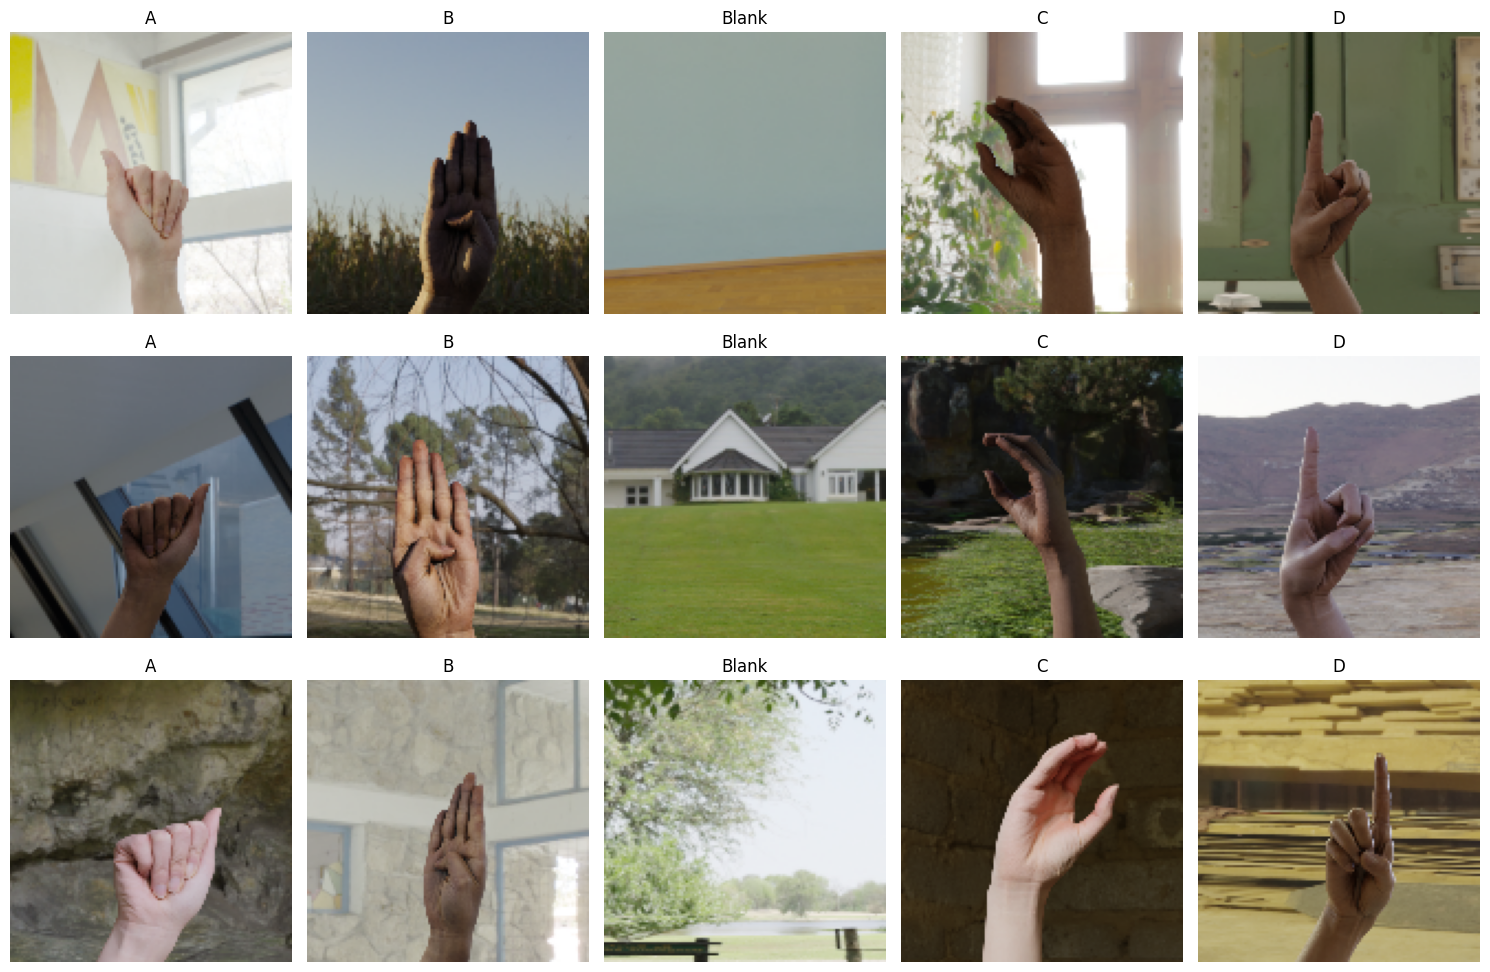

In [19]:
import os
import cv2
import matplotlib.pyplot as plt

dataset_dir = TRAIN_DATASET_DIR

# 1. FIX: Only get ACTUAL directories, ignore all files in the root
classes = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))]
classes = sorted(classes)
print(f"Verified Classes: {classes}")

# Visualize
fig, axes = plt.subplots(3, 5, figsize=(15, 10))

for i, label in enumerate(classes[:5]):
    class_dir = os.path.join(dataset_dir, label)
    
    # 2. FIX: Only get files that end with image extensions
    # This prevents the code from trying to "open" a .csv as an image
    all_files = os.listdir(class_dir)
    img_files = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:3]

    for j, img_name in enumerate(img_files):
        img_path = os.path.join(class_dir, img_name)
        
        # 3. FIX: Final safety check before reading
        img = cv2.imread(img_path)
        
        if img is not None and img.size > 0:
            try:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (128, 128))
                
                axes[j, i].imshow(img)
                axes[j, i].set_title(label)
            except Exception as e:
                axes[j, i].text(0.5, 0.5, 'Error', ha='center')
                print(f"Skipping {img_name}: {e}")
        else:
            # This handles the "Assertion Failed" by not calling cvtColor if img is empty
            axes[j, i].text(0.5, 0.5, 'Empty/Broken', ha='center')
            
        axes[j, i].axis("off")

plt.tight_layout()
plt.show()


In [20]:
img = cv2.imread(img_path)
if img is not None:
    print(f"Original Size: {img.shape}") # Shows (Height, Width, Channels)
else:
    print("This file is definitely broken!")


Original Size: (512, 513, 3)


Data Pre-processing

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Data generators
# We use preprocess_input for MobileNetV2 instead of rescale=1./255
# We also separate validation datagen so it doesn't get augmented!
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=False, # Horizontal flip is bad for ASL (changes hand direction)
    validation_split=0.2  # Splitting data into train (80%) and val (20%)
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

# Train & validation generators (load images directly from disk)
train_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=42
)

print("Class labels:", train_generator.class_indices)


Found 19440 images belonging to 27 classes.
Found 4860 images belonging to 27 classes.
Class labels: {'A': 0, 'B': 1, 'Blank': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'H': 8, 'I': 9, 'J': 10, 'K': 11, 'L': 12, 'M': 13, 'N': 14, 'O': 15, 'P': 16, 'Q': 17, 'R': 18, 'S': 19, 'T': 20, 'U': 21, 'V': 22, 'W': 23, 'X': 24, 'Y': 25, 'Z': 26}


Defining the MobileNet V2 Model

In [22]:
base_model = MobileNetV2(
    weights="imagenet", 
    include_top=False, 
    input_shape=(128, 128, 3)
)

base_model.trainable = False  # Freezing all layers initially as this is an intial training

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(DENSE_UNITS, activation="relu")(x)
x = Dropout(DROPOUT_RATE)(x)
output_layer = Dense(len(train_generator.class_indices), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output_layer)

# Compile model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


I0000 00:00:1777272803.573981      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Initial training on the dataset

In [23]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=INITIAL_EPOCHS 
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1777272817.732987     121 service.cc:152] XLA service 0x78a854142150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777272817.733054     121 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777272818.791920     121 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777272825.047909     121 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


152/152 ━━━━━━━━━━━━━━━━━━━━ 458s 3s/step - accuracy: 0.3103 - loss: 2.4586 - val_accuracy: 0.6551 - val_loss: 1.0595
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.5896 - loss: 1.2896 - val_accuracy: 0.7107 - val_loss: 0.8738
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.6453 - loss: 1.1106 - val_accuracy: 0.7319 - val_loss: 0.8015
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.6623 - loss: 1.0399 - val_accuracy: 0.7374 - val_loss: 0.7807
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.6661 - loss: 1.0091 - val_accuracy: 0.7541 - val_loss: 0.7416
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.6928 - loss: 0.9563 - val_accuracy: 0.7473 - val_loss: 0.7441
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.7041 - loss: 0.9111 - val_accuracy: 0.7628 - val_loss: 0.7007
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.7156 - loss: 0.8805 - val_accuracy: 0.776

Fine Tuning the model further

In [24]:
for layer in base_model.layers[-20:]:  # Unfreeze last 20 layers
    # DO NOT unfreeze BatchNormalization layers! It destroys their moving averages!
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# Recompile with a lower learning rate to avoid overfitting
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LEARN_RATE),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINETUNE_EPOCHS
)


Epoch 1/10


2026-04-27 07:50:41.065748: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 07:50:41.264734: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


136/152 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.7519 - loss: 0.7697

2026-04-27 07:55:03.185290: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 07:55:03.387583: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


152/152 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.7528 - loss: 0.7659 - val_accuracy: 0.8070 - val_loss: 0.5783
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.7779 - loss: 0.6736 - val_accuracy: 0.8128 - val_loss: 0.5399
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.8048 - loss: 0.6011 - val_accuracy: 0.8311 - val_loss: 0.4917
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.8082 - loss: 0.5758 - val_accuracy: 0.8463 - val_loss: 0.4562
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.8283 - loss: 0.5323 - val_accuracy: 0.8455 - val_loss: 0.4526
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - accuracy: 0.8314 - loss: 0.5008 - val_accuracy: 0.8488 - val_loss: 0.4367
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.8315 - loss: 0.4960 - val_accuracy: 0.8578 - val_loss: 0.4109
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.8394 - loss: 0.4705 - val_accuracy: 0.866

In [25]:
model.save(MODEL_SAVE_PATH)
print("Model saved successfully!")


Model saved successfully!


Model Testing

In [26]:
# Load the trained model
model = tf.keras.models.load_model(MODEL_SAVE_PATH)

print("Model loaded successfully!")


Model loaded successfully!


In [27]:
# Generate class labels dynamically based on alphabetical folder sorting
class_labels = {v: k for k, v in train_generator.class_indices.items()}
print(f"Dynamically generated class labels: {class_labels}")


Dynamically generated class labels: {0: 'A', 1: 'B', 2: 'Blank', 3: 'C', 4: 'D', 5: 'E', 6: 'F', 7: 'G', 8: 'H', 9: 'I', 10: 'J', 11: 'K', 12: 'L', 13: 'M', 14: 'N', 15: 'O', 16: 'P', 17: 'Q', 18: 'R', 19: 'S', 20: 'T', 21: 'U', 22: 'V', 23: 'W', 24: 'X', 25: 'Y', 26: 'Z'}


In [28]:
import os
import shutil

# 1. Paths
original_test_dir  = TEST_DATASET_DIR
structured_test_dir = r'/kaggle/working/structured_test'

# 2. Create the main working folder
os.makedirs(structured_test_dir, exist_ok=True)

# 3. Auto-detect the test folder structure
entries = os.listdir(original_test_dir)
already_structured = any(
    os.path.isdir(os.path.join(original_test_dir, e)) for e in entries
)

if already_structured:
    # ── Case A: test folder already has class subfolders (same layout as train) ──
    # Just use it directly — no restructuring needed
    structured_test_dir = original_test_dir
    print(f"✅ Test folder is already structured into class subfolders.")
    print(f"   Using directly: {structured_test_dir}")

else:
    # ── Case B: test folder is flat — all images in root, named like "A_test.jpg" ──
    copied = 0
    skipped = 0
    for img_name in entries:
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            class_name = img_name.split('_')[0]
            class_dir  = os.path.join(structured_test_dir, class_name)
            os.makedirs(class_dir, exist_ok=True)
            shutil.copy(os.path.join(original_test_dir, img_name),
                        os.path.join(class_dir, img_name))
            copied += 1
        else:
            skipped += 1

    if copied == 0:
        print(f"❌ No images found in {original_test_dir}")
        print(f"   Skipped entries: {skipped}. Check TEST_DATASET_DIR path.")
    else:
        print(f"✅ Restructured {copied} images into: {structured_test_dir}")
        print(f"   (Skipped {skipped} non-image entries)")


✅ Test folder is already structured into class subfolders.
   Using directly: /kaggle/input/datasets/lexset/synthetic-asl-alphabet/Test_Alphabet


In [29]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Point to the newly created folder!
# Uses the path determined above (either original or restructured)
test_folder = structured_test_dir

# Use preprocess_input instead of rescale=1./255
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    test_folder,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False, # Very important for evaluation
    classes=list(train_generator.class_indices.keys()) # Forces exact class alignment with training!
)

print(f"Loaded test images from {test_folder}")


Found 2700 images belonging to 27 classes.
Loaded test images from /kaggle/input/datasets/lexset/synthetic-asl-alphabet/Test_Alphabet


In [30]:
# Get model predictions
predictions = model.predict(test_generator)

# Convert probabilities to class labels
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# Print first 10 predictions as a sample
filenames = test_generator.filenames
for i in range(min(10, len(filenames))):
    pred_label = class_labels[predicted_classes[i]]
    true_label = class_labels[true_classes[i]]
    print(f"Image: {filenames[i]} → Predicted as: {pred_label} (True: {true_label})")


22/22 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step
Image: A/081a8b28-7394-4254-95aa-e40f7c8989c8.rgb_0000.png → Predicted as: A (True: A)
Image: A/09a13b4f-b68f-43fd-86e3-5644224490a2.rgb_0000.png → Predicted as: A (True: A)
Image: A/09ea96a0-eb7b-4ce5-8a50-b33f345bc9ef.rgb_0000.png → Predicted as: A (True: A)
Image: A/0de66b7e-1449-4079-bf2c-935ec261ddcb.rgb_0000.png → Predicted as: A (True: A)
Image: A/103a0979-29c7-4519-b341-1d58e3156f92.rgb_0000.png → Predicted as: A (True: A)
Image: A/104391f9-2f98-421a-987f-ccfa77ba9087.rgb_0000.png → Predicted as: A (True: A)
Image: A/12dbcf0a-0862-4684-b93c-5f97c5e08b5f.rgb_0000.png → Predicted as: A (True: A)
Image: A/12dcef9e-2b8e-4e8c-a592-ef66dc7edfd0.rgb_0000.png → Predicted as: A (True: A)
Image: A/13f7c1aa-eb4e-4e98-a68d-eafeb1377f29.rgb_0000.png → Predicted as: A (True: A)
Image: A/1451d4ac-deae-4bcb-9d04-f0f829abf6b8.rgb_0000.png → Predicted as: A (True: A)


Test Accuracy

In [31]:
correct = np.sum(predicted_classes == true_classes)
accuracy = (correct / len(true_classes)) * 100

print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 86.33%


Results Visualisation

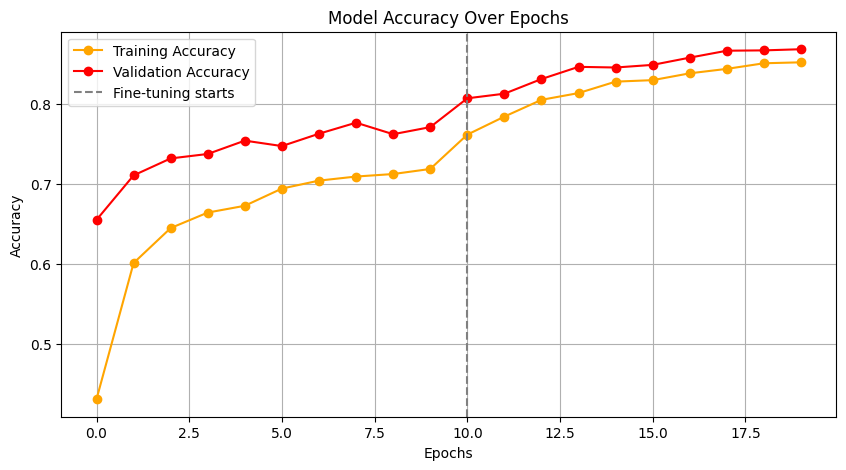

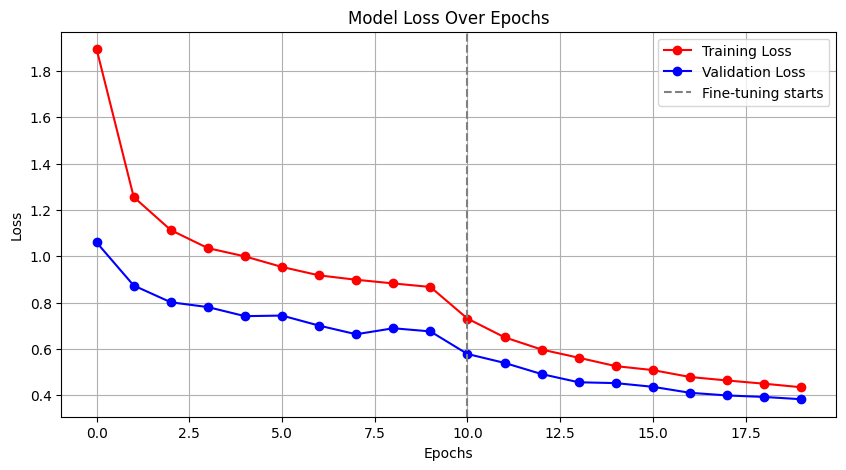

In [32]:
# Combine both training phases for a continuous plot
combined_acc     = history.history["accuracy"]     + history_finetune.history["accuracy"]
combined_val_acc = history.history["val_accuracy"] + history_finetune.history["val_accuracy"]
combined_loss    = history.history["loss"]         + history_finetune.history["loss"]
combined_val_loss= history.history["val_loss"]     + history_finetune.history["val_loss"]

# Mark where fine-tuning starts
finetune_start = len(history.history["accuracy"])

# Plot Accuracy Graph
plt.figure(figsize=(10, 5))
plt.plot(combined_acc,     label="Training Accuracy",   marker="o", color="orange")
plt.plot(combined_val_acc, label="Validation Accuracy", marker="o", color="red")
plt.axvline(x=finetune_start, linestyle="--", color="gray", label="Fine-tuning starts")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss Graph
plt.figure(figsize=(10, 5))
plt.plot(combined_loss,     label="Training Loss",   marker="o", color="red")
plt.plot(combined_val_loss, label="Validation Loss", marker="o", color="blue")
plt.axvline(x=finetune_start, linestyle="--", color="gray", label="Fine-tuning starts")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()


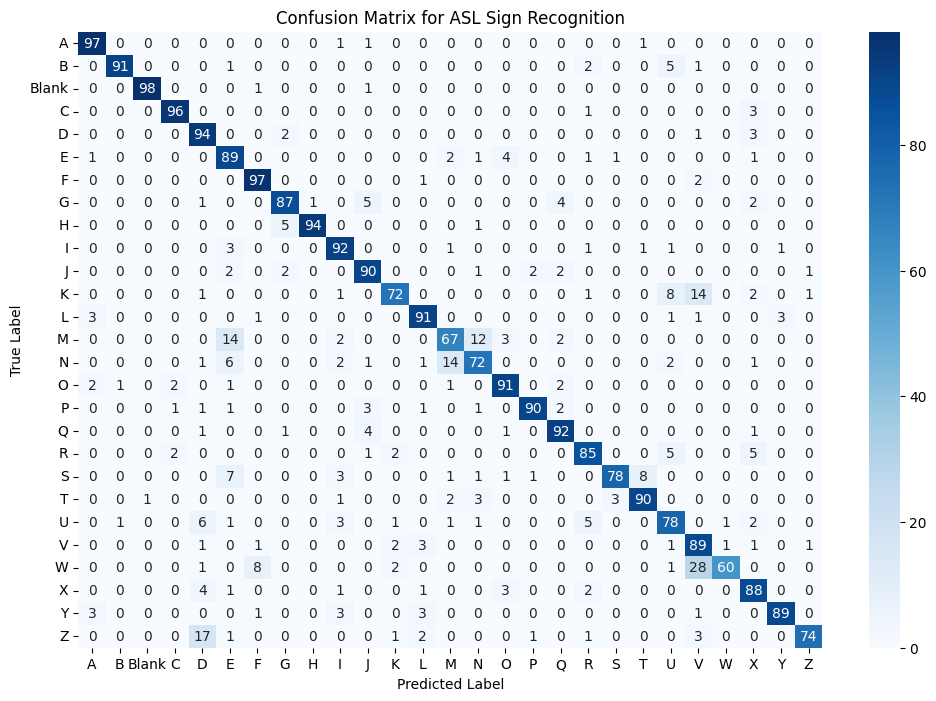

In [33]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

label_names = [class_labels[i] for i in range(len(class_labels))]
cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(len(class_labels))))

# Plot confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for ASL Sign Recognition")
plt.show()


Predicting the Signs from camera feed

- The approach is to use mediapipe to find the center of the hand, make a box/ frame around it, pass the image inside of frame to the trained model.

- Since MobileNet V2 is convolutional neural network, it would not give accurate results on real life data

In [34]:
import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
# Note: We are reusing the dynamically generated `class_labels` dictionary from earlier.

# Load trained MobileNetV2 model
mobilenet_model = tf.keras.models.load_model(MODEL_SAVE_PATH)


mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(min_detection_confidence=0.7, min_tracking_confidence=0.7)

cap = cv2.VideoCapture(0)

#Bounding Box Adjustments
HEIGHT_EXPAND = 220
WIDTH_EXPAND = 150

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb_frame)

    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

            # Get bounding box coordinates
            x_min = min([lm.x for lm in hand_landmarks.landmark]) * frame.shape[1]
            y_min = min([lm.y for lm in hand_landmarks.landmark]) * frame.shape[0]
            x_max = max([lm.x for lm in hand_landmarks.landmark]) * frame.shape[1]
            y_max = max([lm.y for lm in hand_landmarks.landmark]) * frame.shape[0]

            x_min = max(0, int(x_min - WIDTH_EXPAND))   
            y_min = max(0, int(y_min - HEIGHT_EXPAND)) 
            x_max = min(frame.shape[1], int(x_max + WIDTH_EXPAND))  
            y_max = min(frame.shape[0], int(y_max + HEIGHT_EXPAND)) 

            # Crop the hand region
            hand_crop = frame[y_min:y_max, x_min:x_max]

            # Resize to (128x128) for MobileNetV2
            if hand_crop.shape[0] > 0 and hand_crop.shape[1] > 0:
                hand_resized = cv2.resize(hand_crop, (128, 128))
                hand_resized = np.expand_dims(hand_resized, axis=0).astype('float32')
                hand_resized = preprocess_input(hand_resized)  # Correct MobileNetV2 normalization

                # Predict using MobileNetV2
                prediction = mobilenet_model.predict(hand_resized)
                
                # Get top 3 predictions
                top_3_indices = np.argsort(prediction[0])[-3:][::-1]
                top_3_labels = [class_labels[i] for i in top_3_indices]
                top_3_scores = [prediction[0][i] for i in top_3_indices]

                # Debugging: Print top 3 predictions
                print(f"Top 3 Predictions: {list(zip(top_3_labels, top_3_scores))}")

                # Get the best prediction
                predicted_label = top_3_labels[0]

                # Display Prediction
                cv2.putText(frame, f"Predicted: {predicted_label}", (50, 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                
            cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

    cv2.imshow("MobileNetV2 Sign Prediction (Fixed Bounding Box Height)", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
[ WARN:0@6954.362] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
W0000 00:00:1777279696.601231     665 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
[ WARN:0@6954.382] global cap.cpp:438 open VIDEOIO(FFMPEG): raised OpenCV exception:

OpenCV(4.13.0) /io/opencv/modules/videoio/src/cap_ffmpeg_impl.hpp:1220: error: (-2:Unspecified error) in function 'bool CvCapture_FFMPEG::open(const char*, int, const cv::Ptr<cv::IStreamReader>&, const cv::VideoCaptureParameters&)'
> VIDEOIO/FFMPEG: Camera index out of range (expected: 'index < device_list->nb_devices'), where
>     'index' is 0
> must be less than
>     'device_list->nb_devices' is 0


[ERROR:0@6954.383] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range


After testing it is seen that this model is useful and clasifies the signs correctly which has distinct unique shapes like - letter A, L, etc but fails in complex signs like - letter K, X etc.

In [35]:
# ==========================================
# FINAL PROJECT REPORT & PERFORMANCE SUMMARY
# ==========================================
import numpy as np

print("=" * 60)
print("📊 FINAL PROJECT REPORT: MOBILENET-V2 CNN ARCHITECTURE")
print("=" * 60)

# 1. Model Specifications
print("\n🏗️ 1. MODEL SPECIFICATIONS & STRATEGY")
print("- Base Architecture: MobileNetV2 (ImageNet weights)")
print("- Input Shape:       (128, 128, 3)")
try:
    print(f"- Total Parameters:  {model.count_params():,}")
except:
    print("- Total Parameters:  (Model not loaded in memory)")
print(f"- Final Layers:      GlobalAveragePooling2D -> Dropout({DROPOUT_RATE}) -> Dense({len(train_generator.class_indices)})")

# 2. Extract Training Data from History
print("\n📈 2. TRAINING PERFORMANCE")
try:
    # Pulls the exact final numbers from your fine-tuning history
    final_train_acc = history_finetune.history['accuracy'][-1] * 100
    final_val_acc = history_finetune.history['val_accuracy'][-1] * 100
    final_train_loss = history_finetune.history['loss'][-1]
    
    print(f"- Final Training Accuracy:   {final_train_acc:.2f}%")
    print(f"- Final Validation Accuracy: {final_val_acc:.2f}%")
    print(f"- Final Training Loss:       {final_train_loss:.4f}")
except NameError:
    print("- ⚠️ 'history_finetune' not found in memory (Run the training cell first).")

# 3. Test Set Evaluation
print("\n🎯 3. UNSEEN TEST DATA EVALUATION")
try:
    print("Evaluating test set... (this takes a few seconds)")
    test_loss, test_acc = model.evaluate(test_generator, verbose=0)
    print(f"- Official Test Accuracy:    {test_acc * 100:.2f}%")
    print(f"- Official Test Loss:        {test_loss:.4f}")
except Exception as e:
    print(f"- ⚠️ Could not run test evaluation: {e}")

# 4. Conclusion
print("\n📝 4. CONCLUSION & NEXT STEPS")
print("✅ STRENGTHS: The model excels at identifying signs with distinct silhouettes ")
print("   (e.g., 'A', 'L', 'Space').")
print("❌ LIMITATIONS: The CNN struggles with complex overlapping signs (e.g., 'K' vs 'V') ")
print("   where the outer hand shape is identical but internal finger placement changes.")
print("\n🚀 TRANSITION TO MEDIAPIPE:")
print("   Because CNNs rely on raw pixels, we will now transition to 'Mediapipe_Training.ipynb'")
print("   to train an MLP that looks purely at the (x, y, z) skeletal geometry of the hand.")
print("=" * 60)


📊 FINAL PROJECT REPORT: MOBILENET-V2 CNN ARCHITECTURE

🏗️ 1. MODEL SPECIFICATIONS & STRATEGY
- Base Architecture: MobileNetV2 (ImageNet weights)
- Input Shape:       (128, 128, 3)
- Total Parameters:  3,597,403
- Final Layers:      GlobalAveragePooling2D -> Dropout(0.4) -> Dense(27)

📈 2. TRAINING PERFORMANCE
- Final Training Accuracy:   85.20%
- Final Validation Accuracy: 86.83%
- Final Training Loss:       0.4348

🎯 3. UNSEEN TEST DATA EVALUATION
Evaluating test set... (this takes a few seconds)
- Official Test Accuracy:    86.33%
- Official Test Loss:        0.3913

📝 4. CONCLUSION & NEXT STEPS
✅ STRENGTHS: The model excels at identifying signs with distinct silhouettes 
   (e.g., 'A', 'L', 'Space').
❌ LIMITATIONS: The CNN struggles with complex overlapping signs (e.g., 'K' vs 'V') 
   where the outer hand shape is identical but internal finger placement changes.

🚀 TRANSITION TO MEDIAPIPE:
   Because CNNs rely on raw pixels, we will now transition to 'Mediapipe_Training.ipynb'
   t